In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("us_retail_sales.csv")

# Reshape dataset to long format
df_long = df.melt(id_vars="YEAR", var_name="MONTH", value_name="SALES")

# Create datetime column
df_long["DATE"] = pd.to_datetime(df_long["YEAR"].astype(str) + df_long["MONTH"], format="%Y%b")

# Sort by date
df_long = df_long.sort_values("DATE")

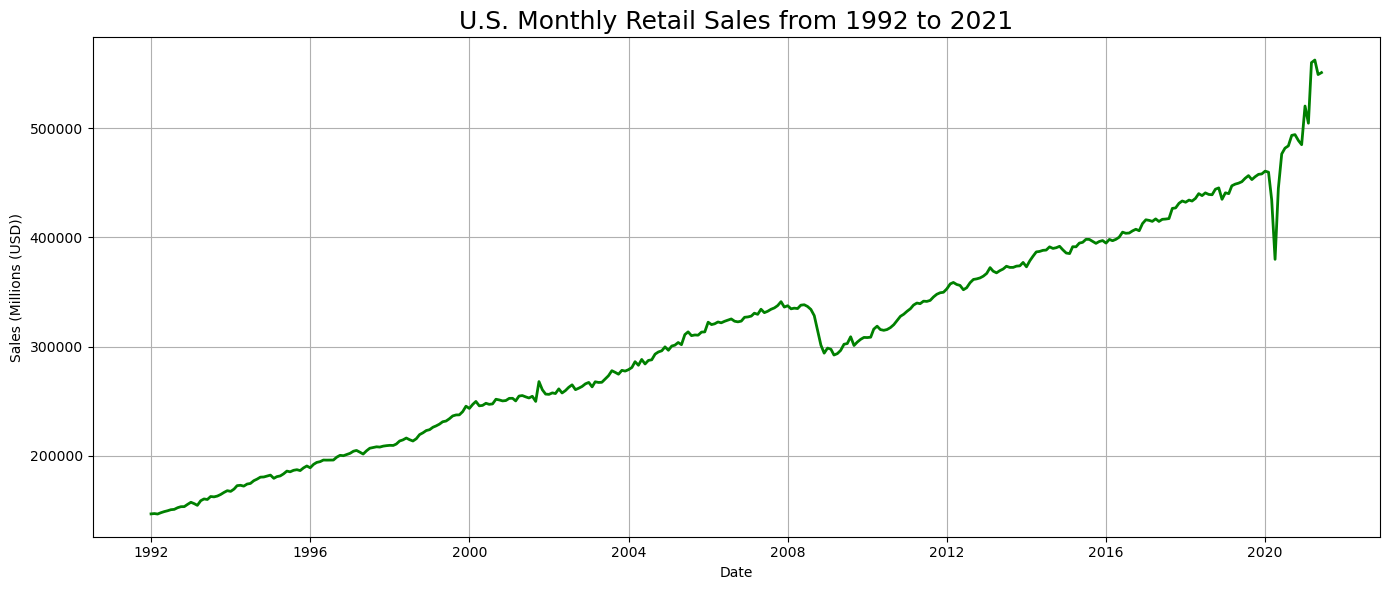

In [61]:
# Plot the dataset

plt.figure(figsize = (14, 6))
plt.plot(df_long["DATE"], df_long["SALES"], color="green", linewidth=2)
plt.title("U.S. Monthly Retail Sales from 1992 to 2021", fontsize = 18)
plt.xlabel("Date")
plt.ylabel("Sales (Millions (USD))")
plt.grid(True)
plt.tight_layout()
plt.show()

The "U.S. Monthly Retail Sales from 1992 to 2021" line chart reveals steady sales increases from 1992 to 2008. At about the mid to the end of 2008, there was a significant dip that did not recover until 2012. The dip in 2008 may be attributed to the 2008 housing crisis impacting U.S. consumerism due to expendable monies being tied up in home expenses. 

From 2012 to 2021, I saw a steady increase resume and a huge drop, even more significant than 2008, in 2020 - 2021, likely due to the impacts that COVID-19 had on the world. Recovery from this event was much quicker and even sees extreme growth, unlike anything on the chart previously. This may have to do with global markets opening back up and the excitement of the U.S. consumer because of that. But, this growth is something to be cautious of because of the now digitally driven shopping experience that U.S. consumers are used to due to the post-COVID-19 shutdown.

In [62]:
### Split the data into a training and test set.

# Check for missing months
expected_months = pd.date_range(start="1992-01-01", end="2021-12-01", freq="MS")
missing_months = expected_months.difference(df_long["DATE"])
print("Missing months:", missing_months)

# Fill missing months with NaN
df_long = df_long.set_index("DATE").reindex(expected_months).reset_index()
df_long.rename(columns={"index": "DATE"}, inplace=True)

Missing months: DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


In [63]:
# Define the test set range: July 2020 to June 2021
test_start= pd.to_datetime("2020-07-01")
test_end = pd.to_datetime("2021-06-30")

# Split the data into test and train sets
df_test = df_long[(df_long["DATE"] >= test_start) & (df_long["DATE"] <= test_end)]
df_train = df_long[df_long["DATE"] < test_start]

# Confirm the split
print("Training set:", df_train.shape)
print("Test set:", df_test.shape)

Training set: (342, 4)
Test set: (12, 4)


In [64]:
### Use the training set to build a predictive model for the monthly retail sales.

# Load and reshape the dataset
df = pd.read_csv("us_retail_sales.csv")
df_long = df.melt(id_vars="YEAR", var_name="MONTH", value_name="SALES")
df_long["DATE"] = pd.to_datetime(df_long["YEAR"].astype(str) + df_long["MONTH"], format="%Y%b")
df_long = df_long.sort_values("DATE")

# Use the full data through June 2021
train = df_long[df_long["DATE"] <= "2021-06-01"]
train.set_index("DATE", inplace=True)
train = train["SALES"].asfreq("MS") # Monthly frequency

In [65]:
import statsmodels.api as sm

# Fit SARIMA model
model = sm.tsa.statespace.SARIMAX(train,
                                  order=(1,1,1),
                                  seasonal_order=(1,1,1,12),
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)
results = model.fit()
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              SALES   No. Observations:                  354
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -3403.906
Date:                            Wed, 29 Oct 2025   AIC                           6817.812
Time:                                    09:03:18   BIC                           6836.761
Sample:                                01-01-1992   HQIC                          6825.373
                                     - 06-01-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4567      0.273      1.671      0.095      -0.079       0.992
ma.L1         -0.5601      0.264   

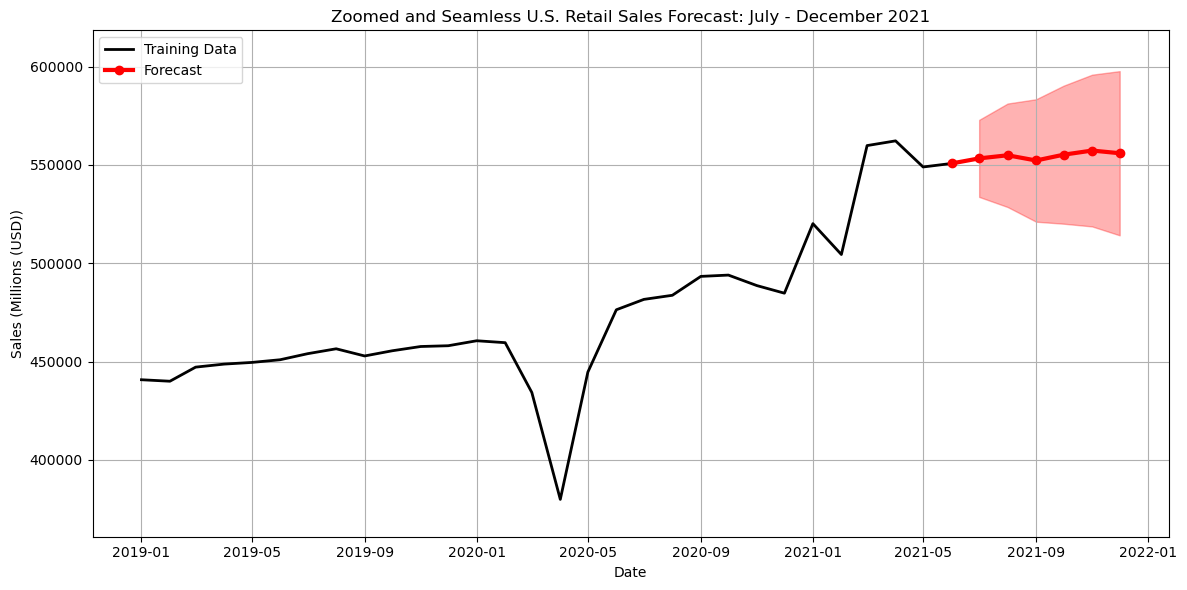

In [66]:
# Forecast July to December 2021
forecast = results.get_forecast(steps=6)
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Create a continuous forecast series starting from the last training point
last_point = train.iloc[-1:]
joined_forecast = pd.concat([last_point, pred_mean])

# Define a zoom window as January 2019 onward
zoom_start = pd.to_datetime("2019-01-01")

# Plot recent training data
plt.figure(figsize=(12, 6))
plt.plot(train.loc[zoom_start:].index,
         train.loc[zoom_start:].values,
         label="Training Data",
         color="black",
         linewidth=2)

# Plot the joined forecast
plt.plot(joined_forecast.index,
         joined_forecast.values,
         label="Forecast",
         color="red",
         linewidth=3,
         marker="o")

# Confidence interval
plt.fill_between(pred_mean.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color="red",
                 alpha=0.3)

# Adjust the y-axis to focus on recent values
y_min = min(train.loc[zoom_start:].min(), pred_mean.min()) * 0.95
y_max = max(train.loc[zoom_start:].max(), pred_mean.max()) * 1.10
plt.ylim(y_min, y_max)

# Final formatting
plt.title("Zoomed and Seamless U.S. Retail Sales Forecast: July - December 2021")
plt.xlabel("Date")
plt.ylabel("Sales (Millions (USD))")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

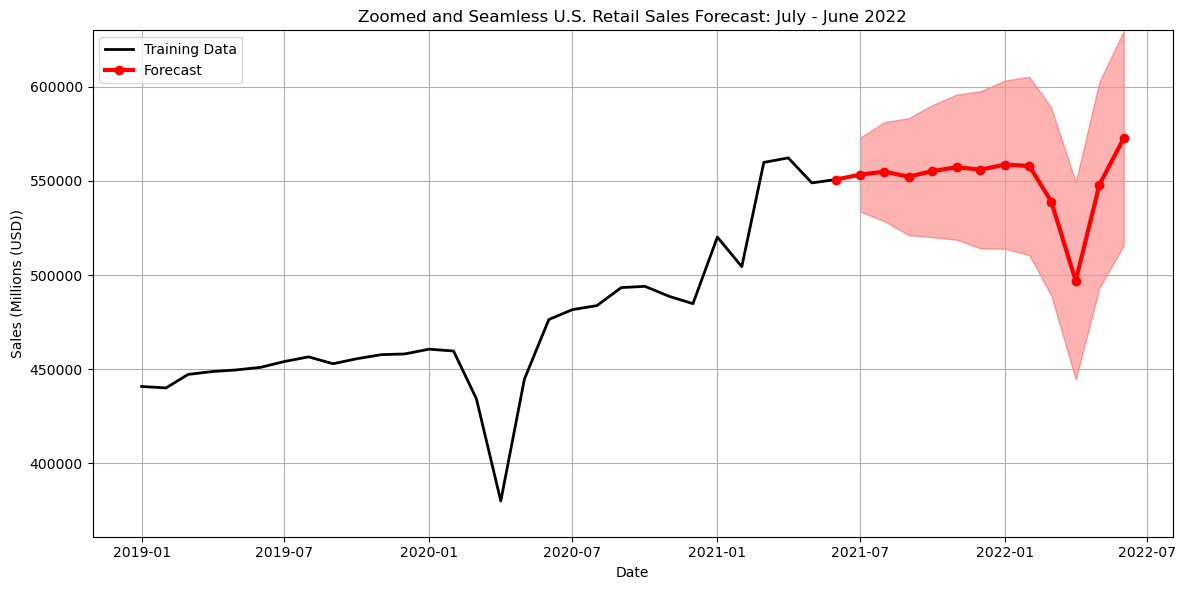

In [67]:
### Use the model to predict the monthly retail sales for the last year of data.

# Forecast 12 months ahead from June 2021
forecast = results.get_forecast(steps=12)
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Create a continuous forecast series starting from the last training point
last_point = train.iloc[-1:]
joined_forecast = pd.concat([last_point, pred_mean])

# Define a zoom window as January 2019 onward
zoom_start = pd.to_datetime("2019-01-01")

# Plot recent training data
plt.figure(figsize=(12, 6))
plt.plot(train.loc[zoom_start:].index,
         train.loc[zoom_start:].values,
         label="Training Data",
         color="black",
         linewidth=2)

# Plot the joined forecast
plt.plot(joined_forecast.index,
         joined_forecast.values,
         label="Forecast",
         color="red",
         linewidth=3,
         marker="o")

# Confidence intervals for the forecast potion
plt.fill_between(pred_mean.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color="red",
                 alpha=0.3)

# Adjust the y-axis to focus on recent values
y_min = min(train.loc[zoom_start:].min(), pred_mean.min()) * 0.95
y_max = max(train.loc[zoom_start:].max(), pred_mean.max()) * 1.10
plt.ylim(y_min, y_max)

# Final formatting
plt.title("Zoomed and Seamless U.S. Retail Sales Forecast: July - June 2022")
plt.xlabel("Date")
plt.ylabel("Sales (Millions (USD))")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [68]:
### Report the RMSE of the model predictions on the test set.

# Split data
train = df_long[df_long["DATE"] <= "2020-06-01"]
test = df_long[(df_long["DATE"] > "2020-06-01") & (df_long["DATE"] <= "2021-06-01")]


# Set index and frequency
train.set_index("DATE", inplace=True)
train = train["SALES"].asfreq("MS")
test.set_index("DATE", inplace=True)
test = test["SALES"].asfreq("MS")

In [69]:
# Fit the model on training data
model = sm.tsa.statespace.SARIMAX(train,
                                   order=(1,1,1),
                                   seasonal_order=(1,1,1,12),
                                   enforce_stationarity=False,
                                   enforce_invertibility=False)
results = model.fit()

# Forecast the test period
forecast = results.get_forecast(steps=12)
pred_mean = forecast.predicted_mean

In [70]:
# Calculate RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, pred_mean))
print(f"RMSE on test set (July 2020 to June 2021): {rmse:.2f}")

RMSE on test set (July 2020 to June 2021): 59819.07


Observation: The RMSE here of 59819.07 translates to approximately $60 billion. This is not a tight RMSE; it is not ideal for the short-term forecast made, but it is still noteworthy, revealing room for improvement.